In [5]:
import yfinance as yf
import pandas as pd

print("Fetching BIST100 blue-chip stocks data (THY, Tupras, Koc Holding)...")
tickers = ['THYAO.IS', 'TUPRS.IS', 'KCHOL.IS']
df_bist = yf.download(tickers, period='1y', interval='1d')['Close']

print("Data fetched successfully! First 5 rows of raw data:")
display(df_bist.head())

Fetching BIST100 blue-chip stocks data (THY, Tupras, Koc Holding)...


[*********************100%***********************]  3 of 3 completed


Data fetched successfully! First 5 rows of raw data:


Ticker,KCHOL.IS,THYAO.IS,TUPRS.IS
Date,,,
2025-04-21,145.075653,307.718506,114.449585
2025-04-22,139.966675,312.602936,115.003822
2025-04-24,141.798203,314.068268,115.742805
2025-04-25,140.255859,310.404938,115.742805
2025-04-28,139.099106,305.520538,114.541962


In [6]:
df_bist.dropna(inplace=True)

df_normalized = (df_bist / df_bist.iloc[0]) * 100

df_returns = df_bist.pct_change().dropna()
corr_matrix = df_returns.corr()

corr_matrix.columns = [col.replace('.IS', '') for col in corr_matrix.columns]
corr_matrix.index = [idx.replace('.IS', '') for idx in corr_matrix.index]

print("Data cleaned and normalized. Correlation matrix calculated!")

Data cleaned and normalized. Correlation matrix calculated!


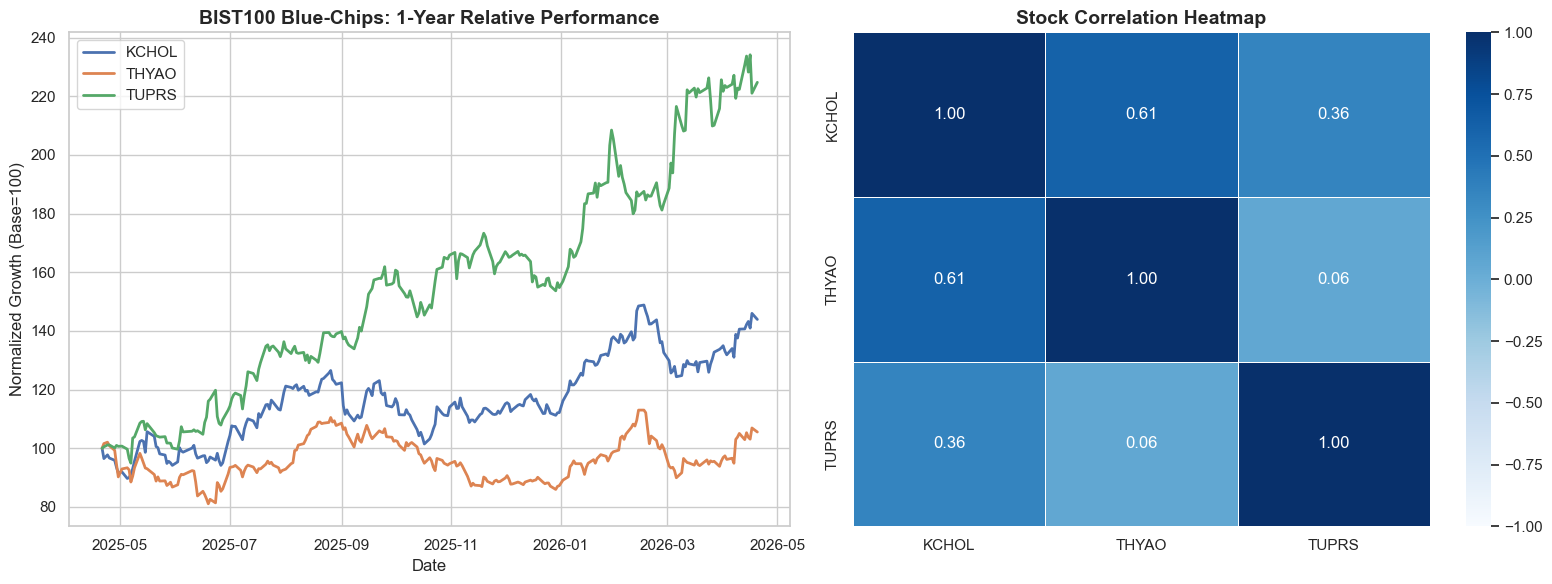


Analysis complete! Visualizations are ready.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col in df_normalized.columns:
    label_name = col.replace('.IS', '') 
    axes[0].plot(df_normalized.index, df_normalized[col], label=label_name, linewidth=2)

axes[0].set_title('BIST100 Blue-Chips: 1-Year Relative Performance', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Normalized Growth (Base=100)', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].legend()

sns.heatmap(corr_matrix, annot=True, cmap='Blues', vmin=-1, vmax=1, linewidths=0.5, fmt=".2f", ax=axes[1])
axes[1].set_title('Stock Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAnalysis complete! Visualizations are ready.")